In [139]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [140]:
#inspecting dataset
df=pd.read_csv('dataset.csv')
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [141]:
#renaming target column as Y
df.rename(columns={'default.payment.next.month': 'Y'}, inplace=True)

Text(0.5, 1.0, 'Data Distribution')

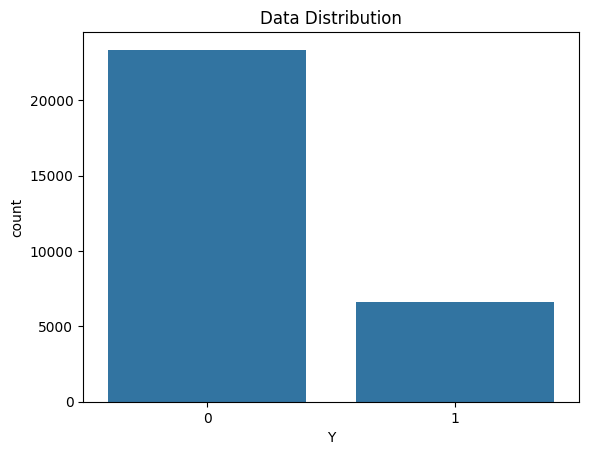

In [142]:
#judging distribution of defaulters Vs non-defaulters
sns.countplot(x='Y',data=df)
plt.title('Data Distribution')

In [143]:
cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

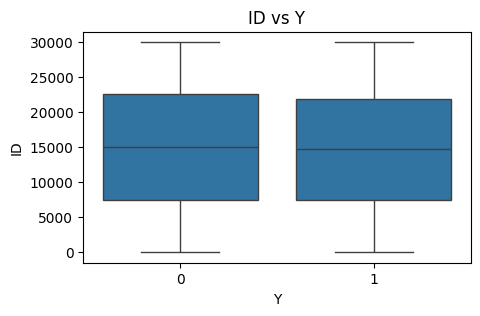

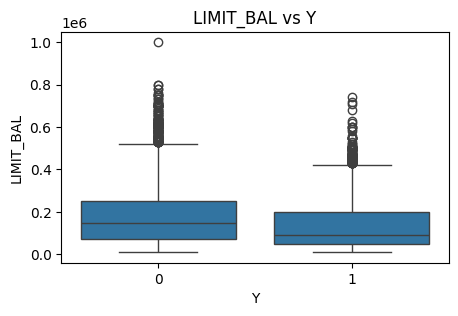

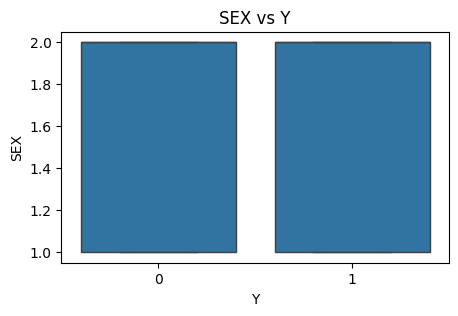

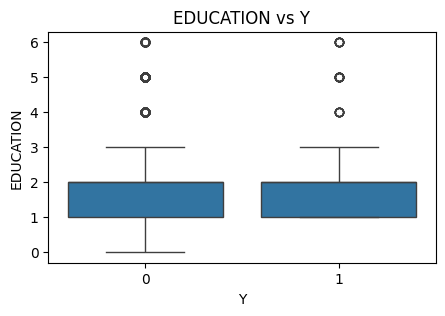

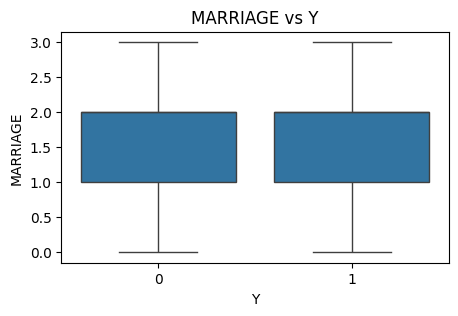

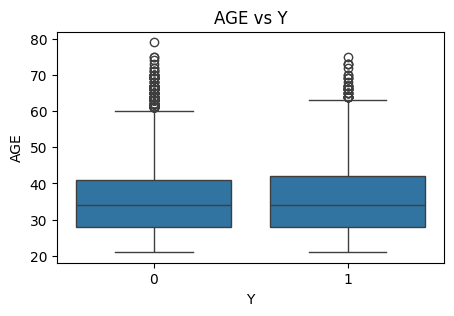

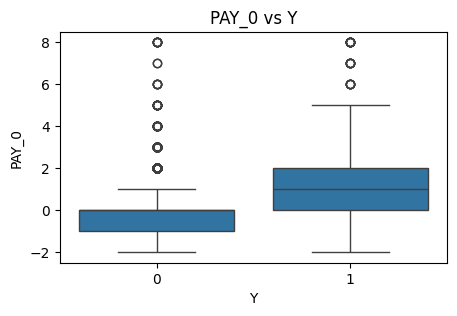

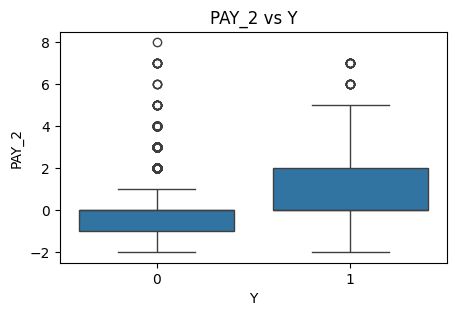

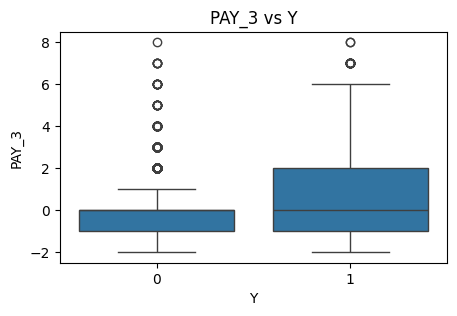

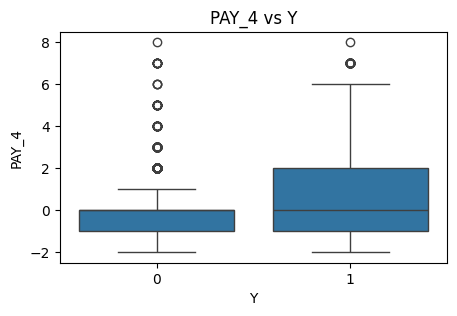

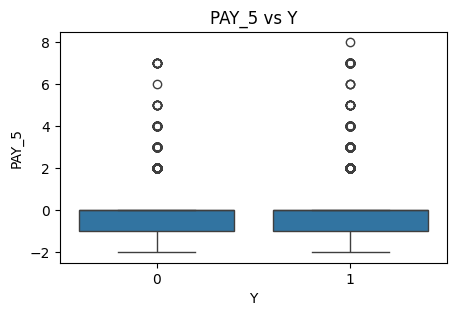

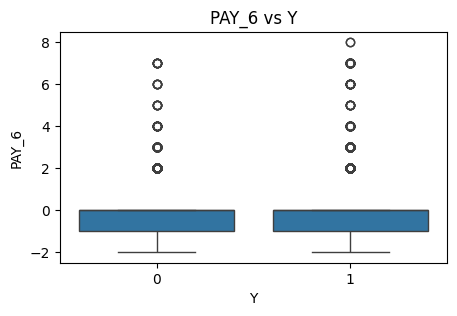

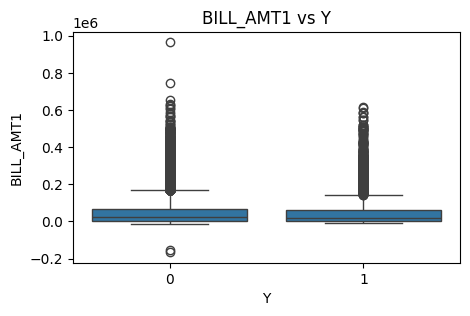

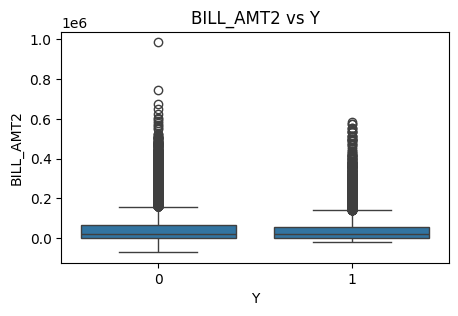

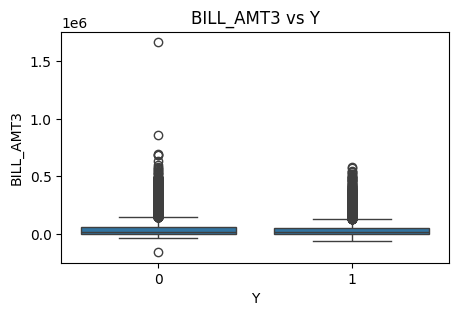

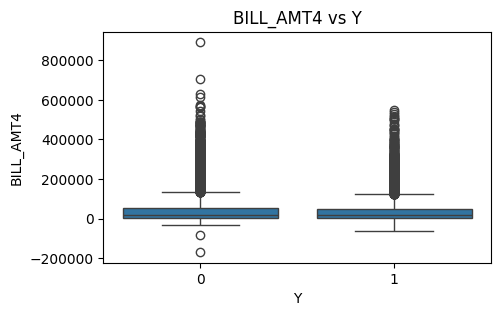

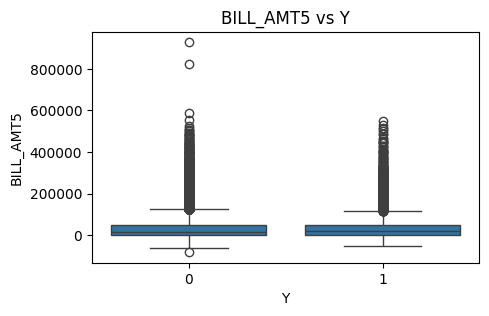

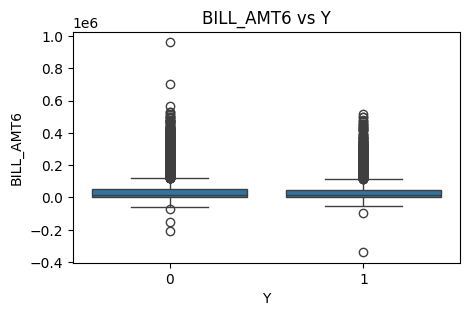

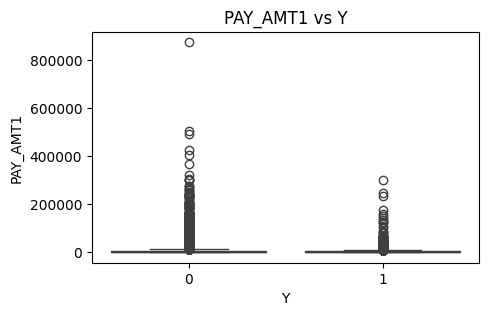

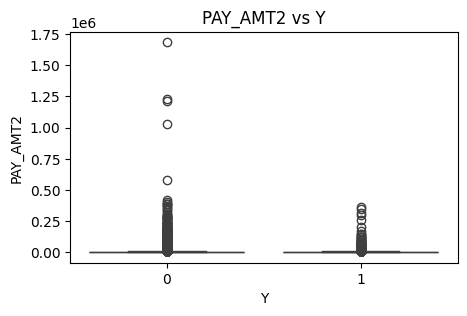

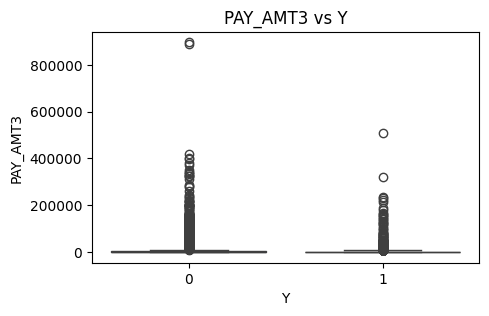

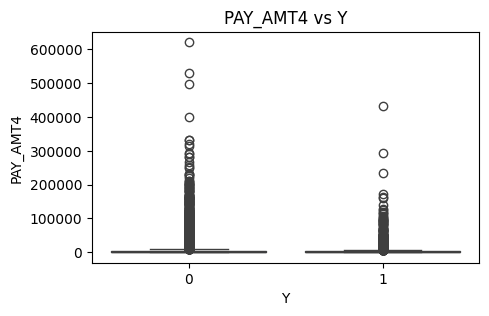

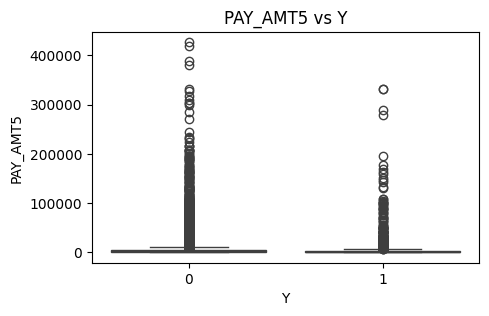

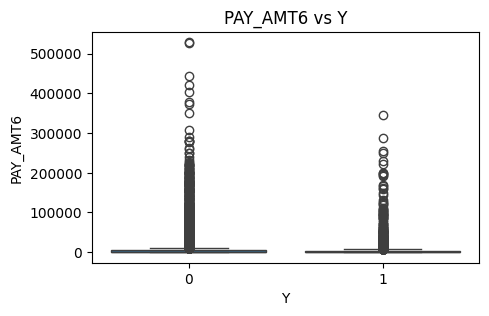

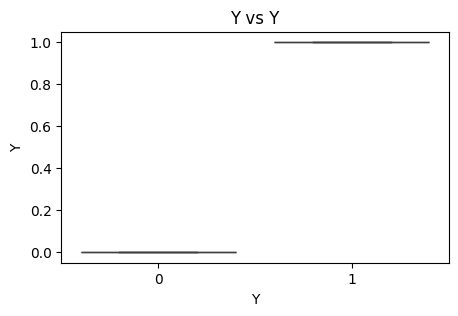

In [144]:
#inspecting which feature columns are varying for defaulters and non-defaulters
for col in cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x='Y', y=col, data=df)
    plt.title(f'{col} vs Y')
    plt.show()

In [145]:
#---DATA PREPPROCESSING---
#Education had 0,5,6 as vague labels which could simply fall under 4 (others)
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
#Marriage had two seperate labels 0 and 3 which are technically one category : others (3)
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

In [146]:
#dropping ID column (data cleaning)
df.drop('ID',axis=1,inplace=True)
#---FEATURE ENGINEERING---
bill_cols=['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_amt_cols=['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']
df['avg_utilization']=df[bill_cols].mean(axis=1)/(df['LIMIT_BAL']+1)
#fixing the skewed pay_amt columns into a more normal distribution
for col in pay_amt_cols:
    df[col]=np.log1p(df[col])
df['missed_payments']=(df[['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']]>0).sum(axis=1)
bill_total=df[bill_cols].clip(lower=0).sum(axis=1) + 1
pay_total=df[pay_amt_cols].sum(axis=1)
df['payment_ratio']=pay_total/bill_total
df['util_trend']=df['BILL_AMT1']-df['BILL_AMT6']
weights=[0.35, 0.25, 0.15, 0.10, 0.08, 0.07]  # recent months weighted higher
df['weighted_util']=sum(w*df[col] for w, col in zip(weights,bill_cols))/df['LIMIT_BAL']
df['LIMIT_BAL']= np.log1p(df['LIMIT_BAL'])
cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

In [147]:
#new dataframe after feature engineering
df.head()
df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Y,avg_utilization,missed_payments,payment_ratio,util_trend,weighted_util
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,11.663016,1.603733,1.842267,1.557267,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,6.283188,6.077716,6.032192,5.932831,0.221200,0.373041,0.834200,0.031716,12351.570500,0.394831
std,0.941120,0.489129,0.744494,0.521405,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,3.349722,3.396598,3.443995,3.528092,0.415062,0.351882,1.554303,0.610050,43922.421534,0.370506
min,9.210440,1.000000,1.000000,1.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,-0.232585,0.000000,0.000000,-428791.000000,-0.348885
25%,10.819798,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,5.968708,5.693732,5.535358,4.777014,0.000000,0.029997,0.000000,0.000101,-2963.000000,0.030428
50%,11.849405,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.496097,7.313887,7.313887,7.313887,0.000000,0.284829,0.000000,0.000245,923.000000,0.305395
75%,12.388398,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,8.413165,8.297606,8.302142,8.294300,0.000000,0.687927,1.000000,0.000839,19793.750000,0.748475
max,13.815512,2.000000,4.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,13.705741,13.339088,12.963438,13.178114,1.000000,5.364040,6.000000,42.558659,708323.000000,5.843964


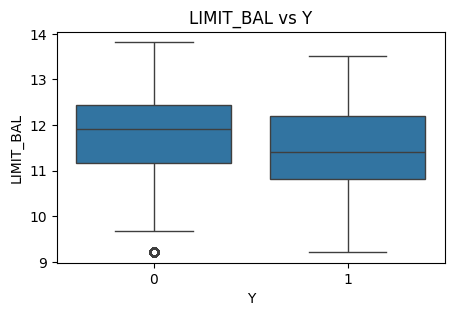

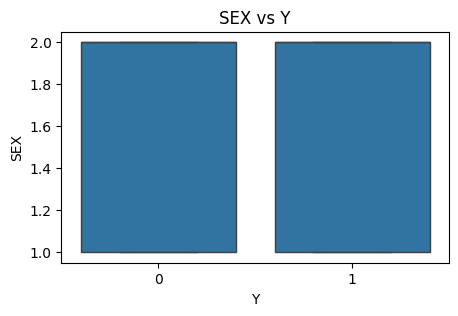

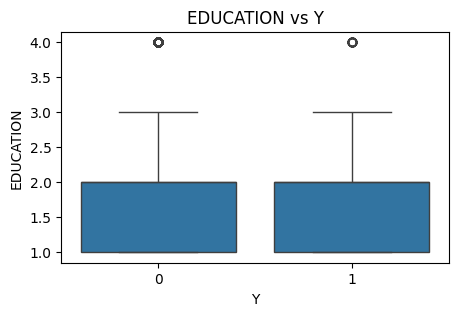

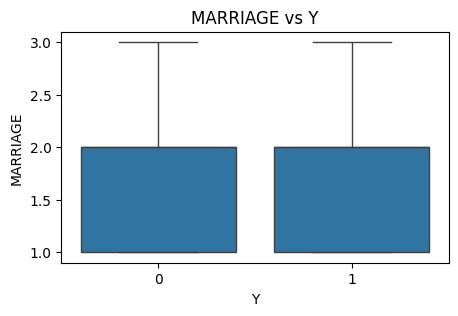

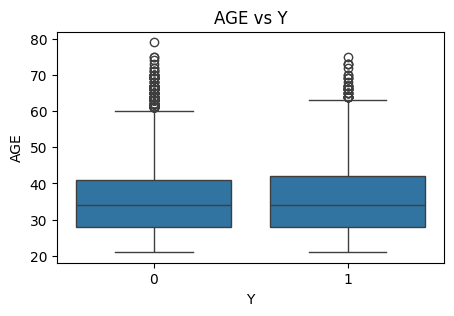

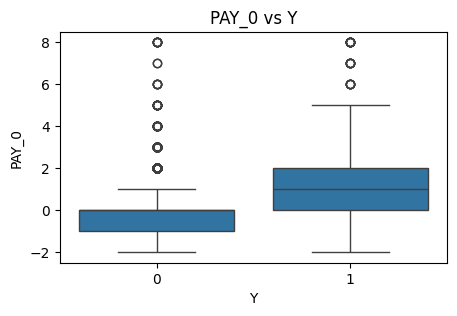

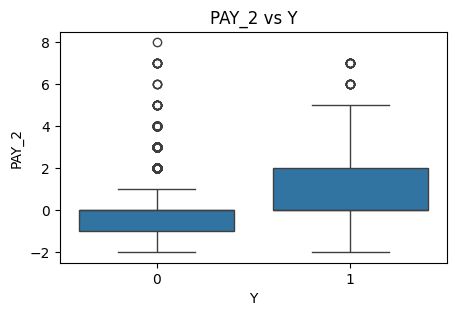

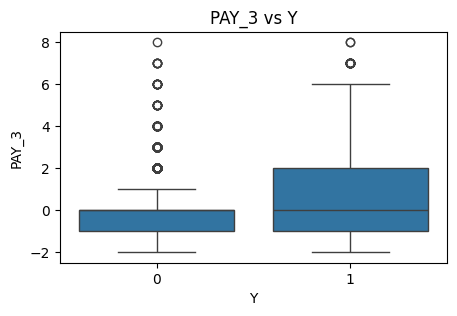

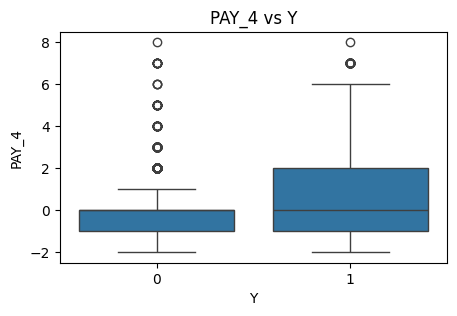

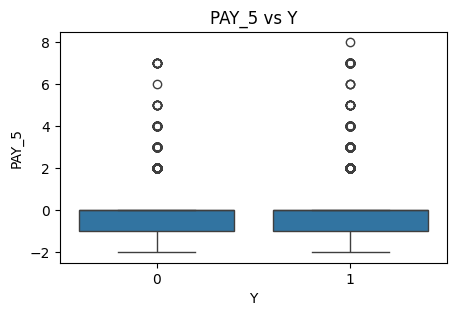

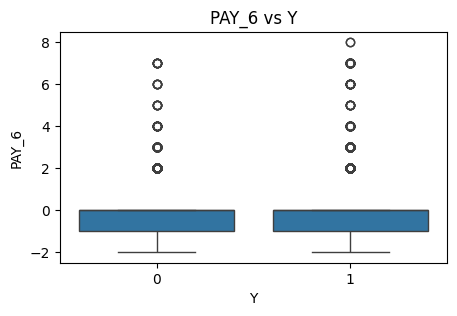

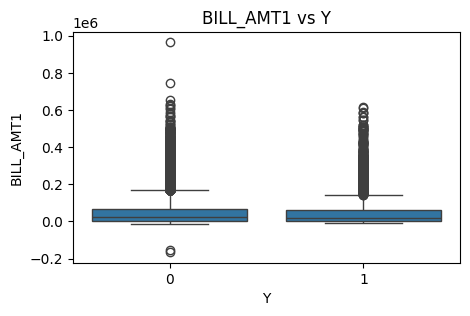

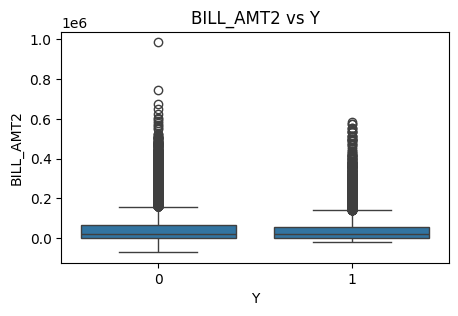

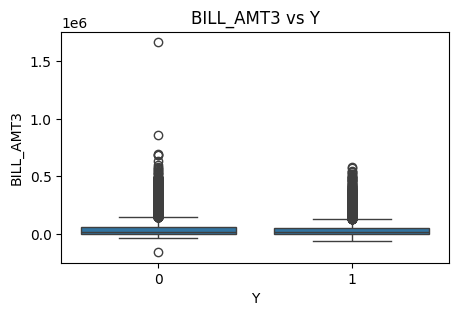

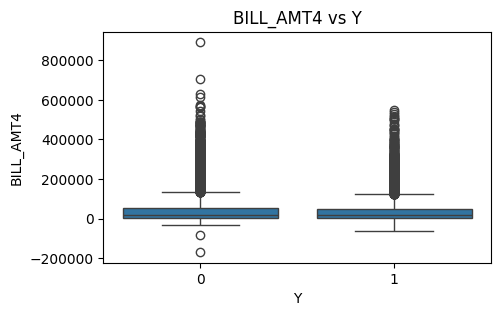

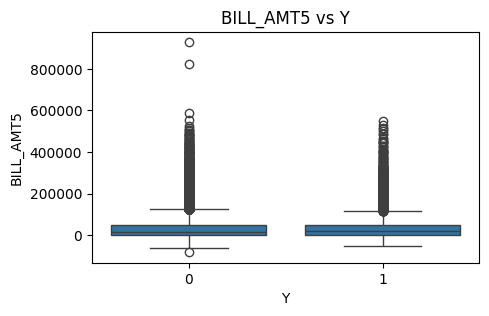

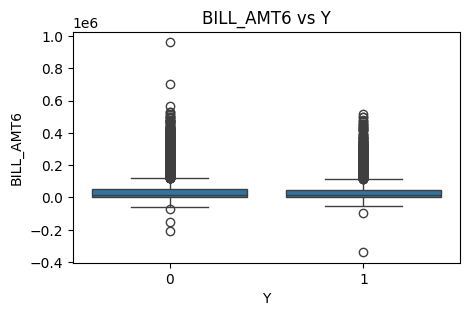

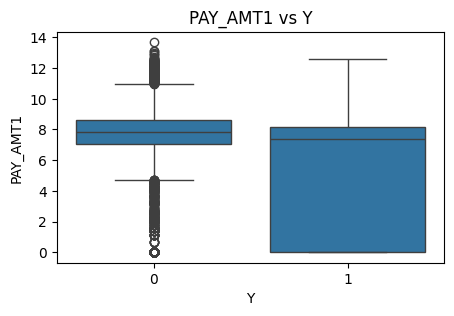

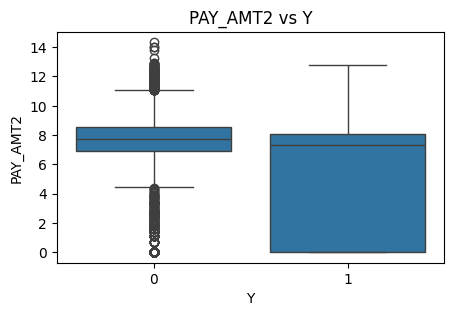

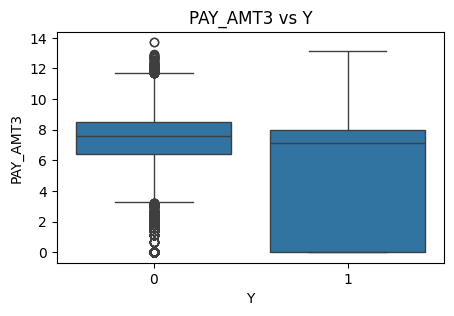

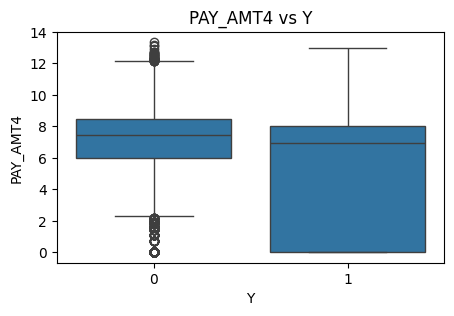

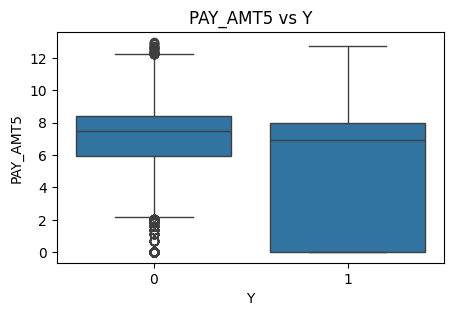

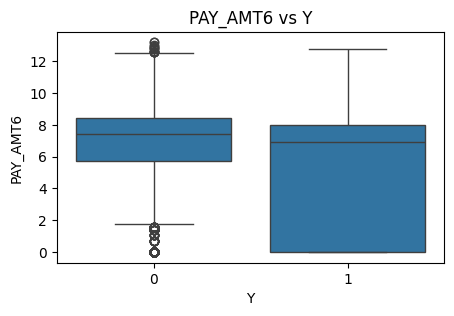

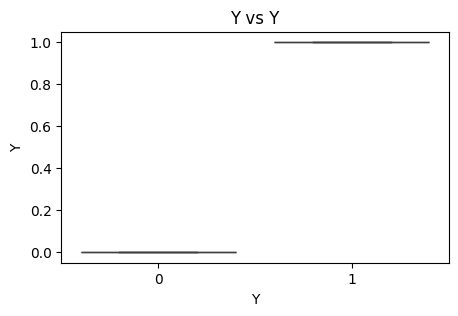

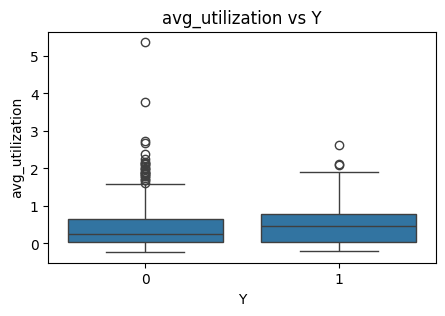

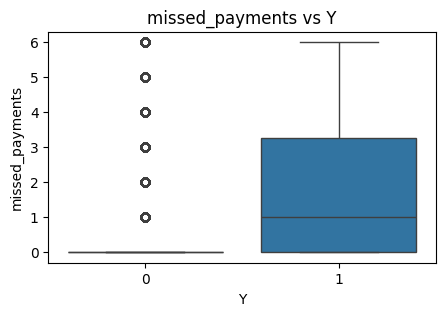

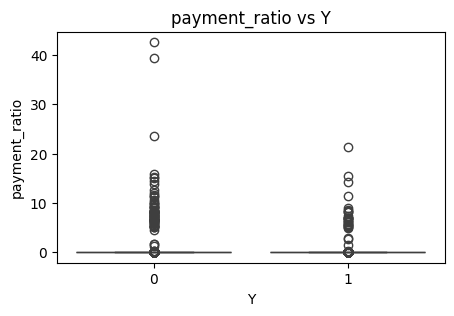

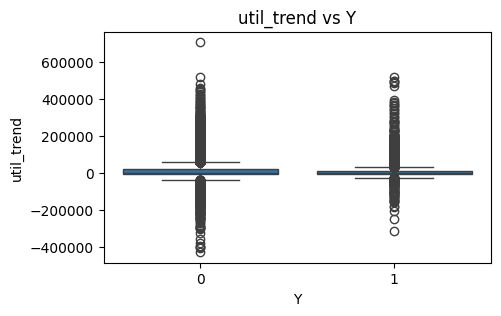

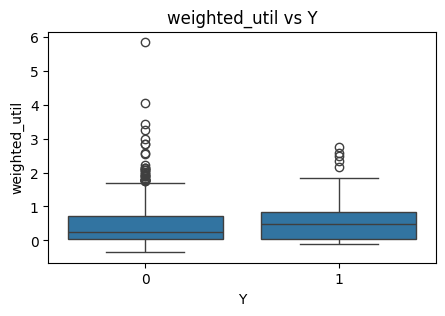

In [148]:
#re-inspecting the distribution of feature columns over Y
for col in cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x='Y', y=col, data=df)
    plt.title(f'{col} vs Y')
    plt.show()

In [149]:
#splitting into training and testing sets
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Y'])
y = df['Y']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)
print(X_train.shape, X_test.shape)


(24000, 28) (6000, 28)


In [150]:
#ratio of non-defaulters to defaulters
ratio=((y==0).sum())/((y==1).sum())
print("Number of non-defaulters to that of non-defaulters: ", ratio)

Number of non-defaulters to that of non-defaulters:  3.5207956600361663


In [151]:
#importing models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [152]:
#training the 4 models: Decision Tree, Random Forest, XGBoost and LightGBM
models={
    'Decision Tree':DecisionTreeClassifier(
        max_depth=5,
        class_weight='balanced',
        random_state=42
    ),
    'Random Forest':RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost':XGBClassifier(
        n_estimators=100,
        scale_pos_weight=3.5,
        eval_metric='logloss',
        random_state=42,
        verbosity=0
    ),
    'LightGBM':LGBMClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        verbosity=-1
    )
}
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'{name} trained ✓')

Decision Tree trained ✓
Random Forest trained ✓
XGBoost trained ✓
LightGBM trained ✓


In [153]:
#importing libraries for model evaluation
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

In [154]:
#evaluating and comparing AUC score, Precision, Recall and F1-Score of the 4 models
results={}
roc_data={}

for name,model in models.items():
    y_pred=model.predict(X_test)
    y_prob=model.predict_proba(X_test)[:,1]
    auc=roc_auc_score(y_test,y_prob)
    fpr,tpr,_=roc_curve(y_test,y_prob)
    report=classification_report(y_test,y_pred,output_dict=True)
    results[name]={
        'AUC':round(auc,4),
        'Precision':round(report['1']['precision'],4),
        'Recall':round(report['1']['recall'],4),
        'F1-Score':round(report['1']['f1-score'],4)
    }
    roc_data[name]=(fpr,tpr,auc)
results_df=pd.DataFrame(results).T.sort_values('AUC',ascending=False)
print(results_df)

                  AUC  Precision  Recall  F1-Score
LightGBM       0.7713     0.4587  0.6157    0.5257
Decision Tree  0.7607     0.4332  0.6157    0.5086
XGBoost        0.7574     0.4560  0.5742    0.5083
Random Forest  0.7537     0.6375  0.3459    0.4485


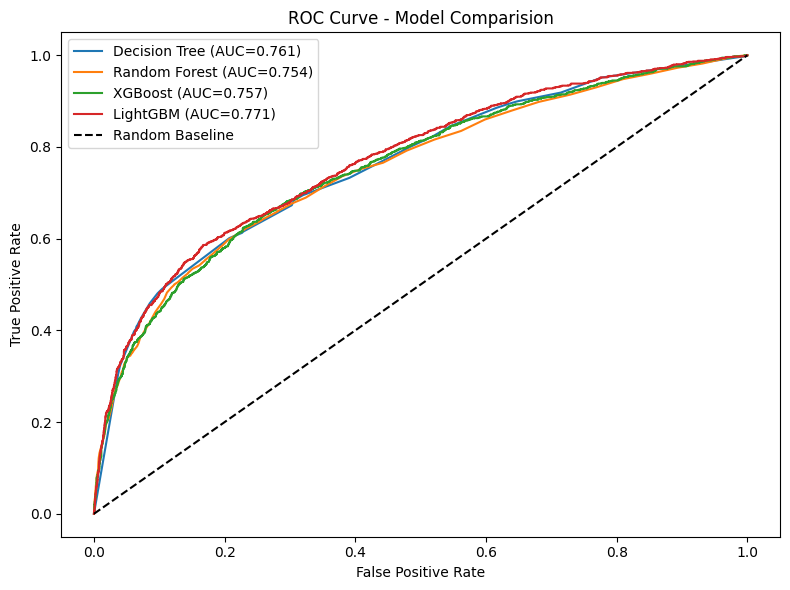

In [155]:
#comparing the ROC curve for each model
plt.figure(figsize=(8,6))
for name,(fpr,tpr,auc) in roc_data.items():
    plt.plot(fpr,tpr,label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--',label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model Comparision')
plt.legend()
plt.tight_layout()
plt.show()

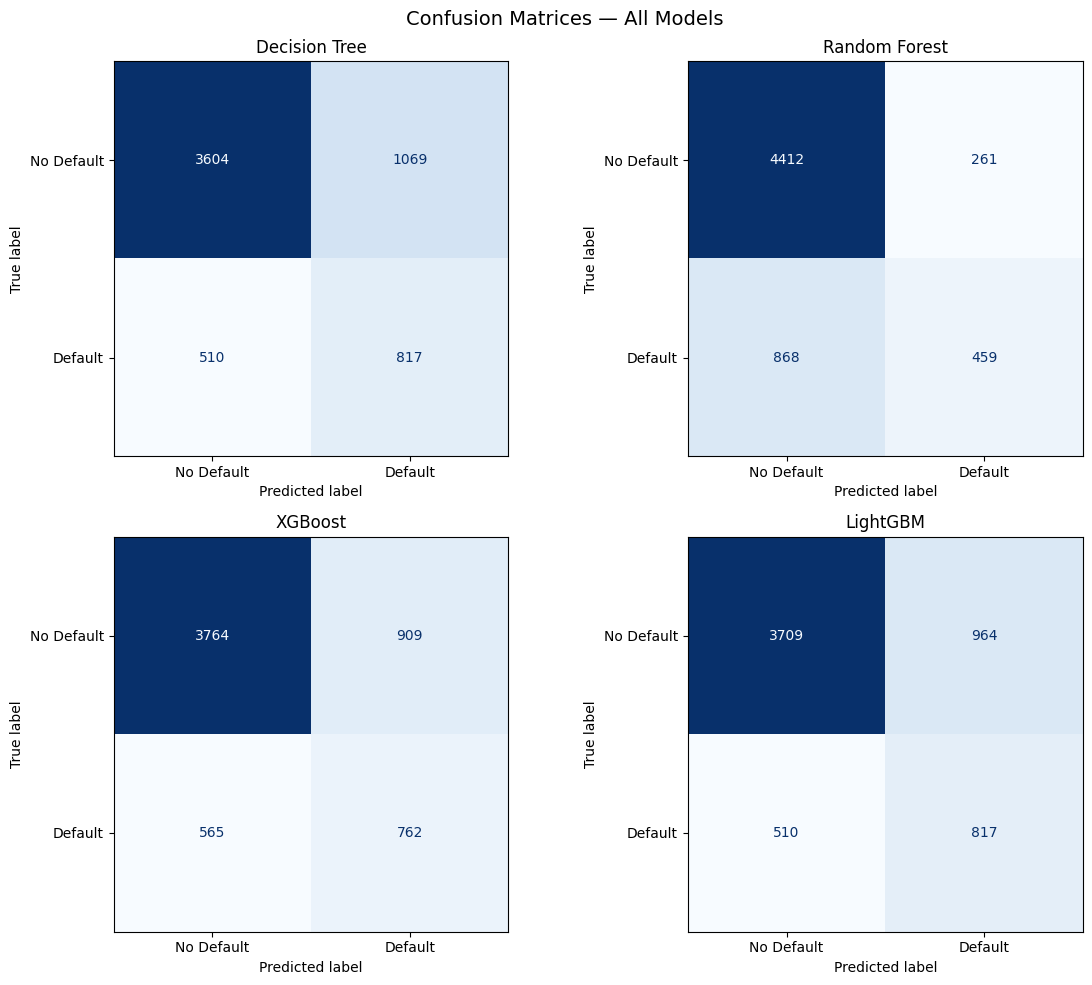

In [156]:
#displaying and comparing confusion matrices for all 4 models
fig,axes=plt.subplots(2,2,figsize=(12,10))
axes=axes.flatten()

for i,(name,model) in enumerate(models.items()):
    y_pred=model.predict(X_test)
    cm=confusion_matrix(y_test, y_pred)
    disp=ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(name)

plt.suptitle('Confusion Matrices — All Models', fontsize=14)
plt.tight_layout()
plt.show()

Best Model: LightGBM
{'AUC': 0.7713, 'Precision': 0.4587, 'Recall': 0.6157, 'F1-Score': 0.5257}


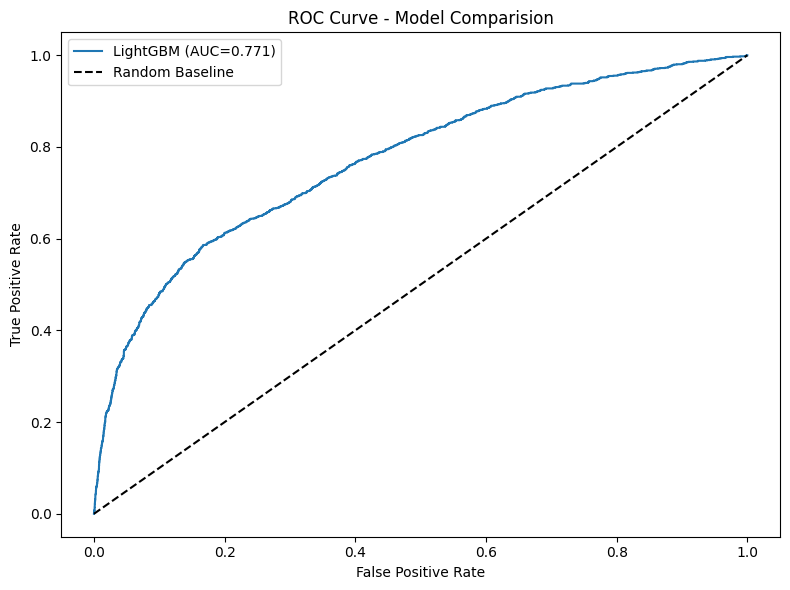

LightGBM although catches 19 defaulters less than decision tree it is superior in terms of
AUC score, 164 lesser False Positives i.e. bothers lesser non-defaulter customers
and lesser useless investigations which would costly to the bank too and more importantly
it would ruin valuable relationship with the customer and LightGBM is superior to Decision
Tree in terms of Precision and F1-Score as well


In [157]:
#Selecting LightGBM as the best performing model
print("Best Model: LightGBM")
print(results['LightGBM'])
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f'{'LightGBM'} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--',label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model Comparision')
plt.legend()
plt.tight_layout()
plt.show()
print("LightGBM although catches 19 defaulters less than decision tree it is superior in terms of\nAUC score, 164 lesser False Positives i.e. bothers lesser non-defaulter customers\nand lesser useless investigations which would costly to the bank too and more importantly\nit would ruin valuable relationship with the customer and LightGBM is superior to Decision\nTree in terms of Precision and F1-Score as well")


In [158]:
#Fine-tuning LightGBM hyper-parameters using Randomised Search CV
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators':[100, 200, 300],
    'max_depth':[4, 6, 8, -1],
    'learning_rate':[0.01, 0.05, 0.1],
    'num_leaves':[31, 50, 70],
    'min_child_samples':[20, 50, 100]
}

search=RandomizedSearchCV(
    LGBMClassifier(class_weight='balanced', random_state=42, verbosity=-1),
    param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)
search.fit(X_train, y_train)
#finding the best parameters for LightGBM
print("Best CV AUC:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

Best CV AUC: 0.7879
Best params: {'num_leaves': 31, 'n_estimators': 100, 'min_child_samples': 50, 'max_depth': 6, 'learning_rate': 0.05}


In [159]:
#Classification Report for the fine-tuned LightGBM
best_lgbm = search.best_estimator_
y_pred_tuned=best_lgbm.predict(X_test)
y_prob_tuned=best_lgbm.predict_proba(X_test)[:, 1]
print("Tuned LightGBM Test AUC:", round(roc_auc_score(y_test, y_prob_tuned), 4))
print()
print(classification_report(y_test, y_pred_tuned, target_names=['No Default', 'Default']))

Tuned LightGBM Test AUC: 0.7787

              precision    recall  f1-score   support

  No Default       0.88      0.80      0.84      4673
     Default       0.46      0.62      0.53      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.71      0.68      6000
weighted avg       0.79      0.76      0.77      6000



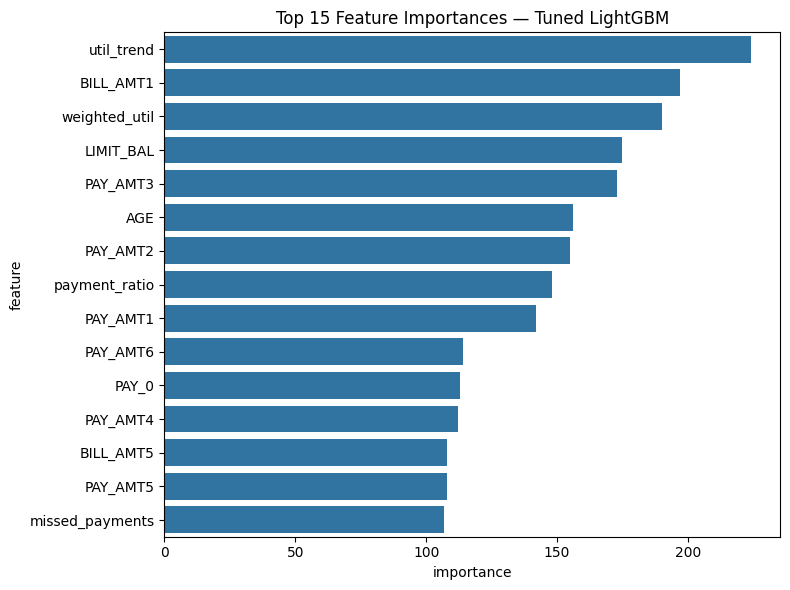

In [160]:
#finding the top 15 important features in the dataset
importance_df = pd.DataFrame({
    'feature':X_train.columns,
    'importance': best_lgbm.feature_importances_
}).sort_values('importance', ascending=False).head(15)
#(Engineered feature: util_trend turned out to be the most important feature for LightGBM)
plt.figure(figsize=(8, 6))
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title('Top 15 Feature Importances — Tuned LightGBM')
plt.tight_layout()
plt.show()

c:\Users\KIIT0001\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


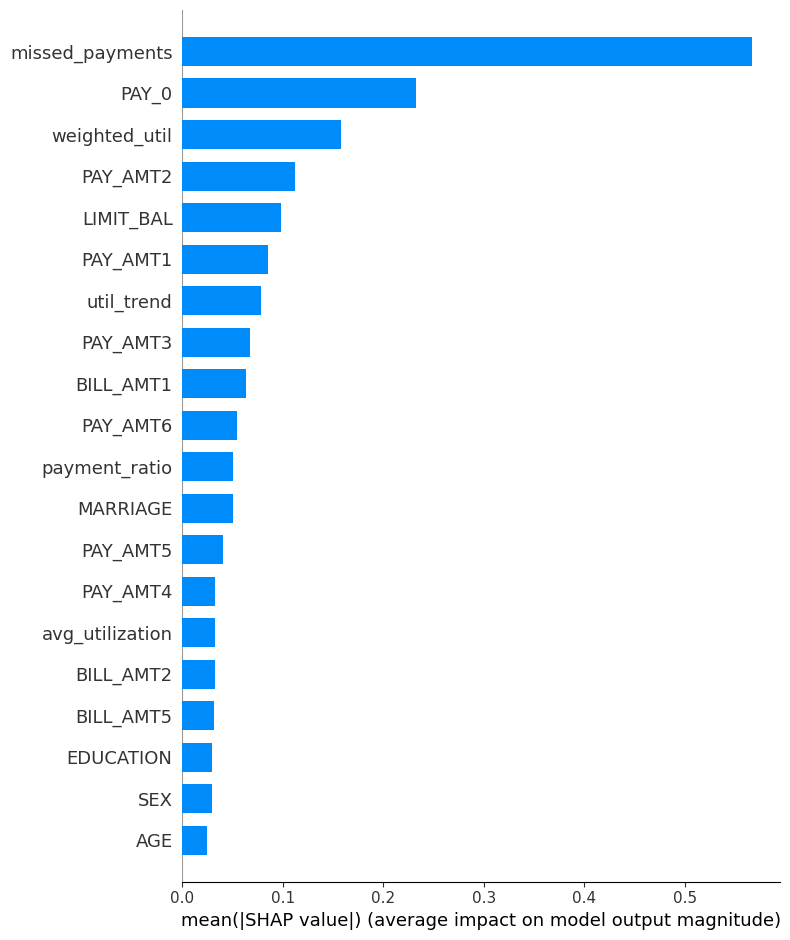

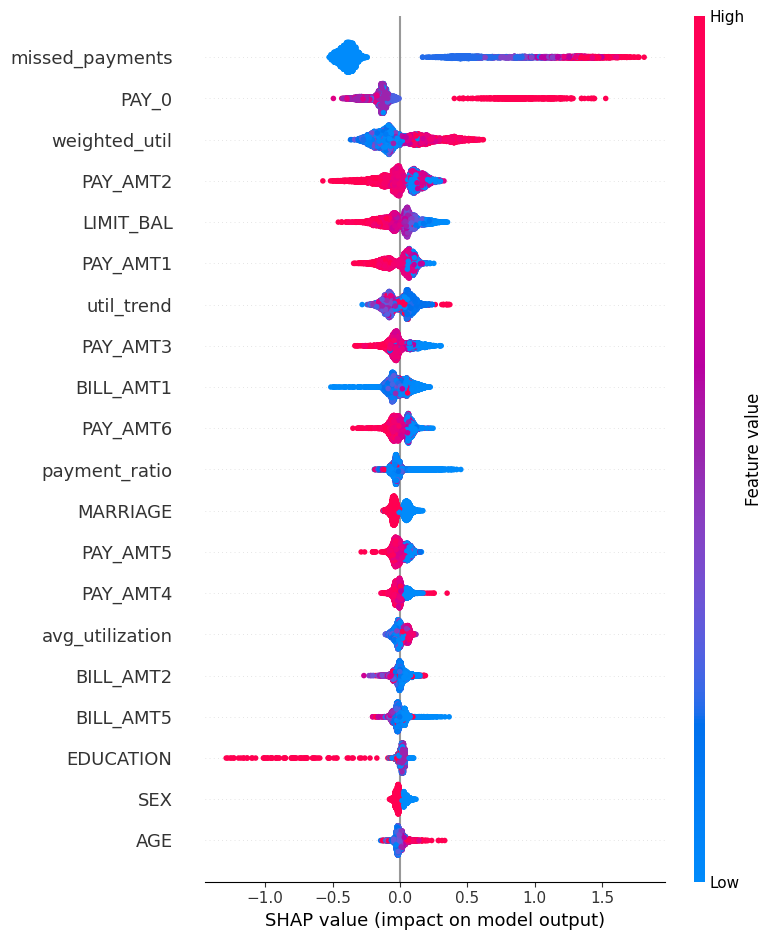

In [161]:
#Visualising the impact of the features on LightGBM using SHAP 
import shap

explainer=shap.TreeExplainer(best_lgbm)
shap_values=explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type='bar')
shap.summary_plot(shap_values, X_test)

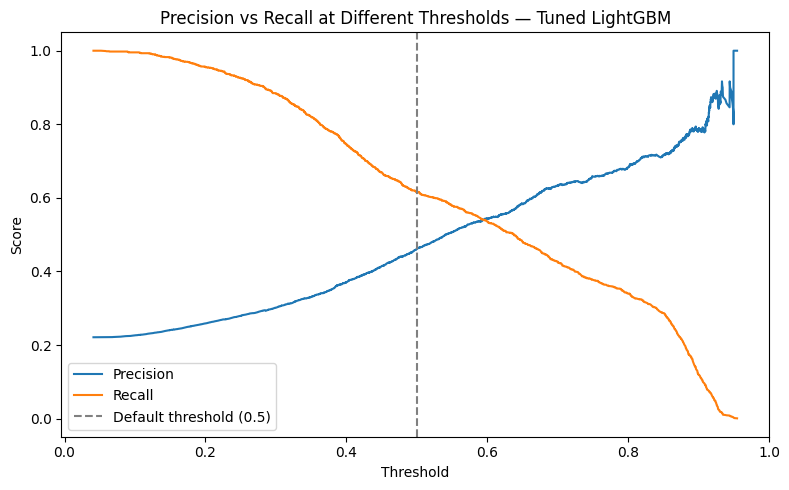

Optimal threshold: 0.469
              precision    recall  f1-score   support

  No Default       0.88      0.76      0.82      4673
     Default       0.43      0.65      0.52      1327

    accuracy                           0.73      6000
   macro avg       0.66      0.70      0.67      6000
weighted avg       0.78      0.73      0.75      6000



In [162]:
#threshold tuning by comparing Precision Vs Recall
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds=precision_recall_curve(y_test, y_prob_tuned)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1],label='Precision')
plt.plot(thresholds, recalls[:-1],label='Recall')
plt.axvline(x=0.5, color='grey',linestyle='--',label='Default threshold (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall at Different Thresholds — Tuned LightGBM')
plt.legend()
plt.tight_layout()
plt.show()

# find threshold where recall>=0.65 and precision is maximised
best_idx=np.argmax(precisions[(recalls >= 0.65)])
best_threshold=thresholds[np.where(recalls >= 0.65)[0][best_idx]]
print(f"Optimal threshold: {best_threshold:.3f}")

y_pred_optimal=(y_prob_tuned >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_optimal, target_names=['No Default', 'Default']))

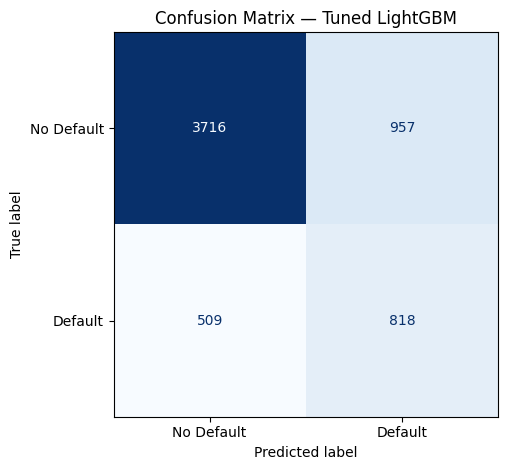

Saved: risk_model.pkl


In [163]:
import joblib

# confusion matrix for tuned model
y_pred_tuned=best_lgbm.predict(X_test)
cm=confusion_matrix(y_test, y_pred_tuned)
disp=ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Tuned LightGBM')
plt.tight_layout()
plt.show()

# saving the final model
joblib.dump(best_lgbm, 'risk_model.pkl')
print("Saved: risk_model.pkl")